In [50]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib
from matplotlib.collections import LineCollection

matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
# plt.style.use('dark_background')

import pickle, gzip
import torch
from torch_geometric.data import Data

In [5]:
with gzip.open('graph_fid_0.pkl.gz', 'rb') as f:
    G = pickle.load(f)

N = G.number_of_nodes()
E = G.number_of_edges()

print(N, E)

440410 2162502


In [8]:
x = torch.tensor([[G.nodes[i]['PVOID'],
                   G.nodes[i]['PSHEET'],
                   G.nodes[i]['PFILAMENT'],
                   G.nodes[i]['PKNOT']] for i in range(N)], dtype=torch.float32)
x.shape

torch.Size([440410, 4])

In [9]:
pos = torch.tensor(np.array([G.nodes[i]['pos'] for i in range(N)]), dtype=torch.float32)
pos.shape

torch.Size([440410, 3])

In [10]:
node_type = torch.tensor([0 if G.nodes[i]['node_type'] == 'halo' else 1 for i in range(N)], dtype=torch.long)
node_type

tensor([0, 0, 0,  ..., 1, 1, 1])

In [11]:
print((node_type == 0).sum())
print((node_type == 1).sum())

tensor(309740)
tensor(130670)


In [17]:
edges = np.array(list(G.edges()), dtype=np.int64)

edge_index = torch.tensor(edges.T, dtype=torch.long)
edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
edge_index.shape

torch.Size([2, 8650008])

In [21]:
edge_distance = torch.tensor([data['distance'] for _, _, data in G.edges(data=True)], dtype=torch.float32)

edge_distance = torch.cat([edge_distance, edge_distance])
edge_distance.shape

torch.Size([4325004])

In [25]:
edge_attr = edge_distance[:, None]
edge_attr.shape

torch.Size([4325004, 1])

In [26]:
edge_type_map = {'HH': 0, 'RR': 1}

edge_type = torch.tensor([edge_type_map[data['edge_type']] for _, _, data in G.edges(data=True)], dtype=torch.long)
edge_type = torch.cat([edge_type, edge_type])

0 = halo-halo

1 = random-random

<!-- 2 = halo-random -->

In [24]:
edge_type

tensor([0, 0, 0,  ..., 1, 1, 1])

In [28]:
data = Data(x=x, pos=pos, edge_index=edge_index, edge_attr=edge_attr)

data.node_type = node_type
data.edge_type = edge_type

Data(
    x=[N, 4],
    pos=[N, 3],
    edge_index=[2, 2E],
    edge_attr=[2E, 1],
    node_type=[N],
    edge_type=[2E]
)

In [29]:
data

Data(x=[440410, 4], edge_index=[2, 8650008], edge_attr=[4325004, 1], pos=[440410, 3], node_type=[440410], edge_type=[4325004])

In [30]:
data.halo_mask = node_type == 0
data.random_mask = node_type == 1

In [32]:
data.x[data.halo_mask].shape, data.x[data.random_mask].shape

(torch.Size([309740, 4]), torch.Size([130670, 4]))

In [33]:
with open('delta_dm_randoms_R10.pkl', 'rb') as f:
    delta_dm_rand = pickle.load(f)

In [36]:
delta_dm_rand = torch.as_tensor(delta_dm_rand, dtype=torch.float32)

In [37]:
data.y = torch.full((N,), float('nan'), dtype=torch.float32)
data.y[data.random_mask] = delta_dm_rand

In [38]:
print('randoms in graph:', data.random_mask.sum().item())
print('rho dm:', len(delta_dm_rand))

randoms in graph: 130670
rho dm: 130670


In [39]:
assert data.random_mask.sum().item() == len(delta_dm_rand)

----

In [66]:
z0 = 500.0
dz = 50.0

In [67]:
pos_np = data.pos.cpu().numpy()
y_np = data.y.cpu().numpy()
random_mask = data.random_mask.cpu().numpy()

In [68]:
mask = (random_mask & (np.abs(pos_np[:, 2] - z0) < dz/2))

In [69]:
p = pos_np[mask]
delta = y_np[mask]
p.shape

(6623, 3)

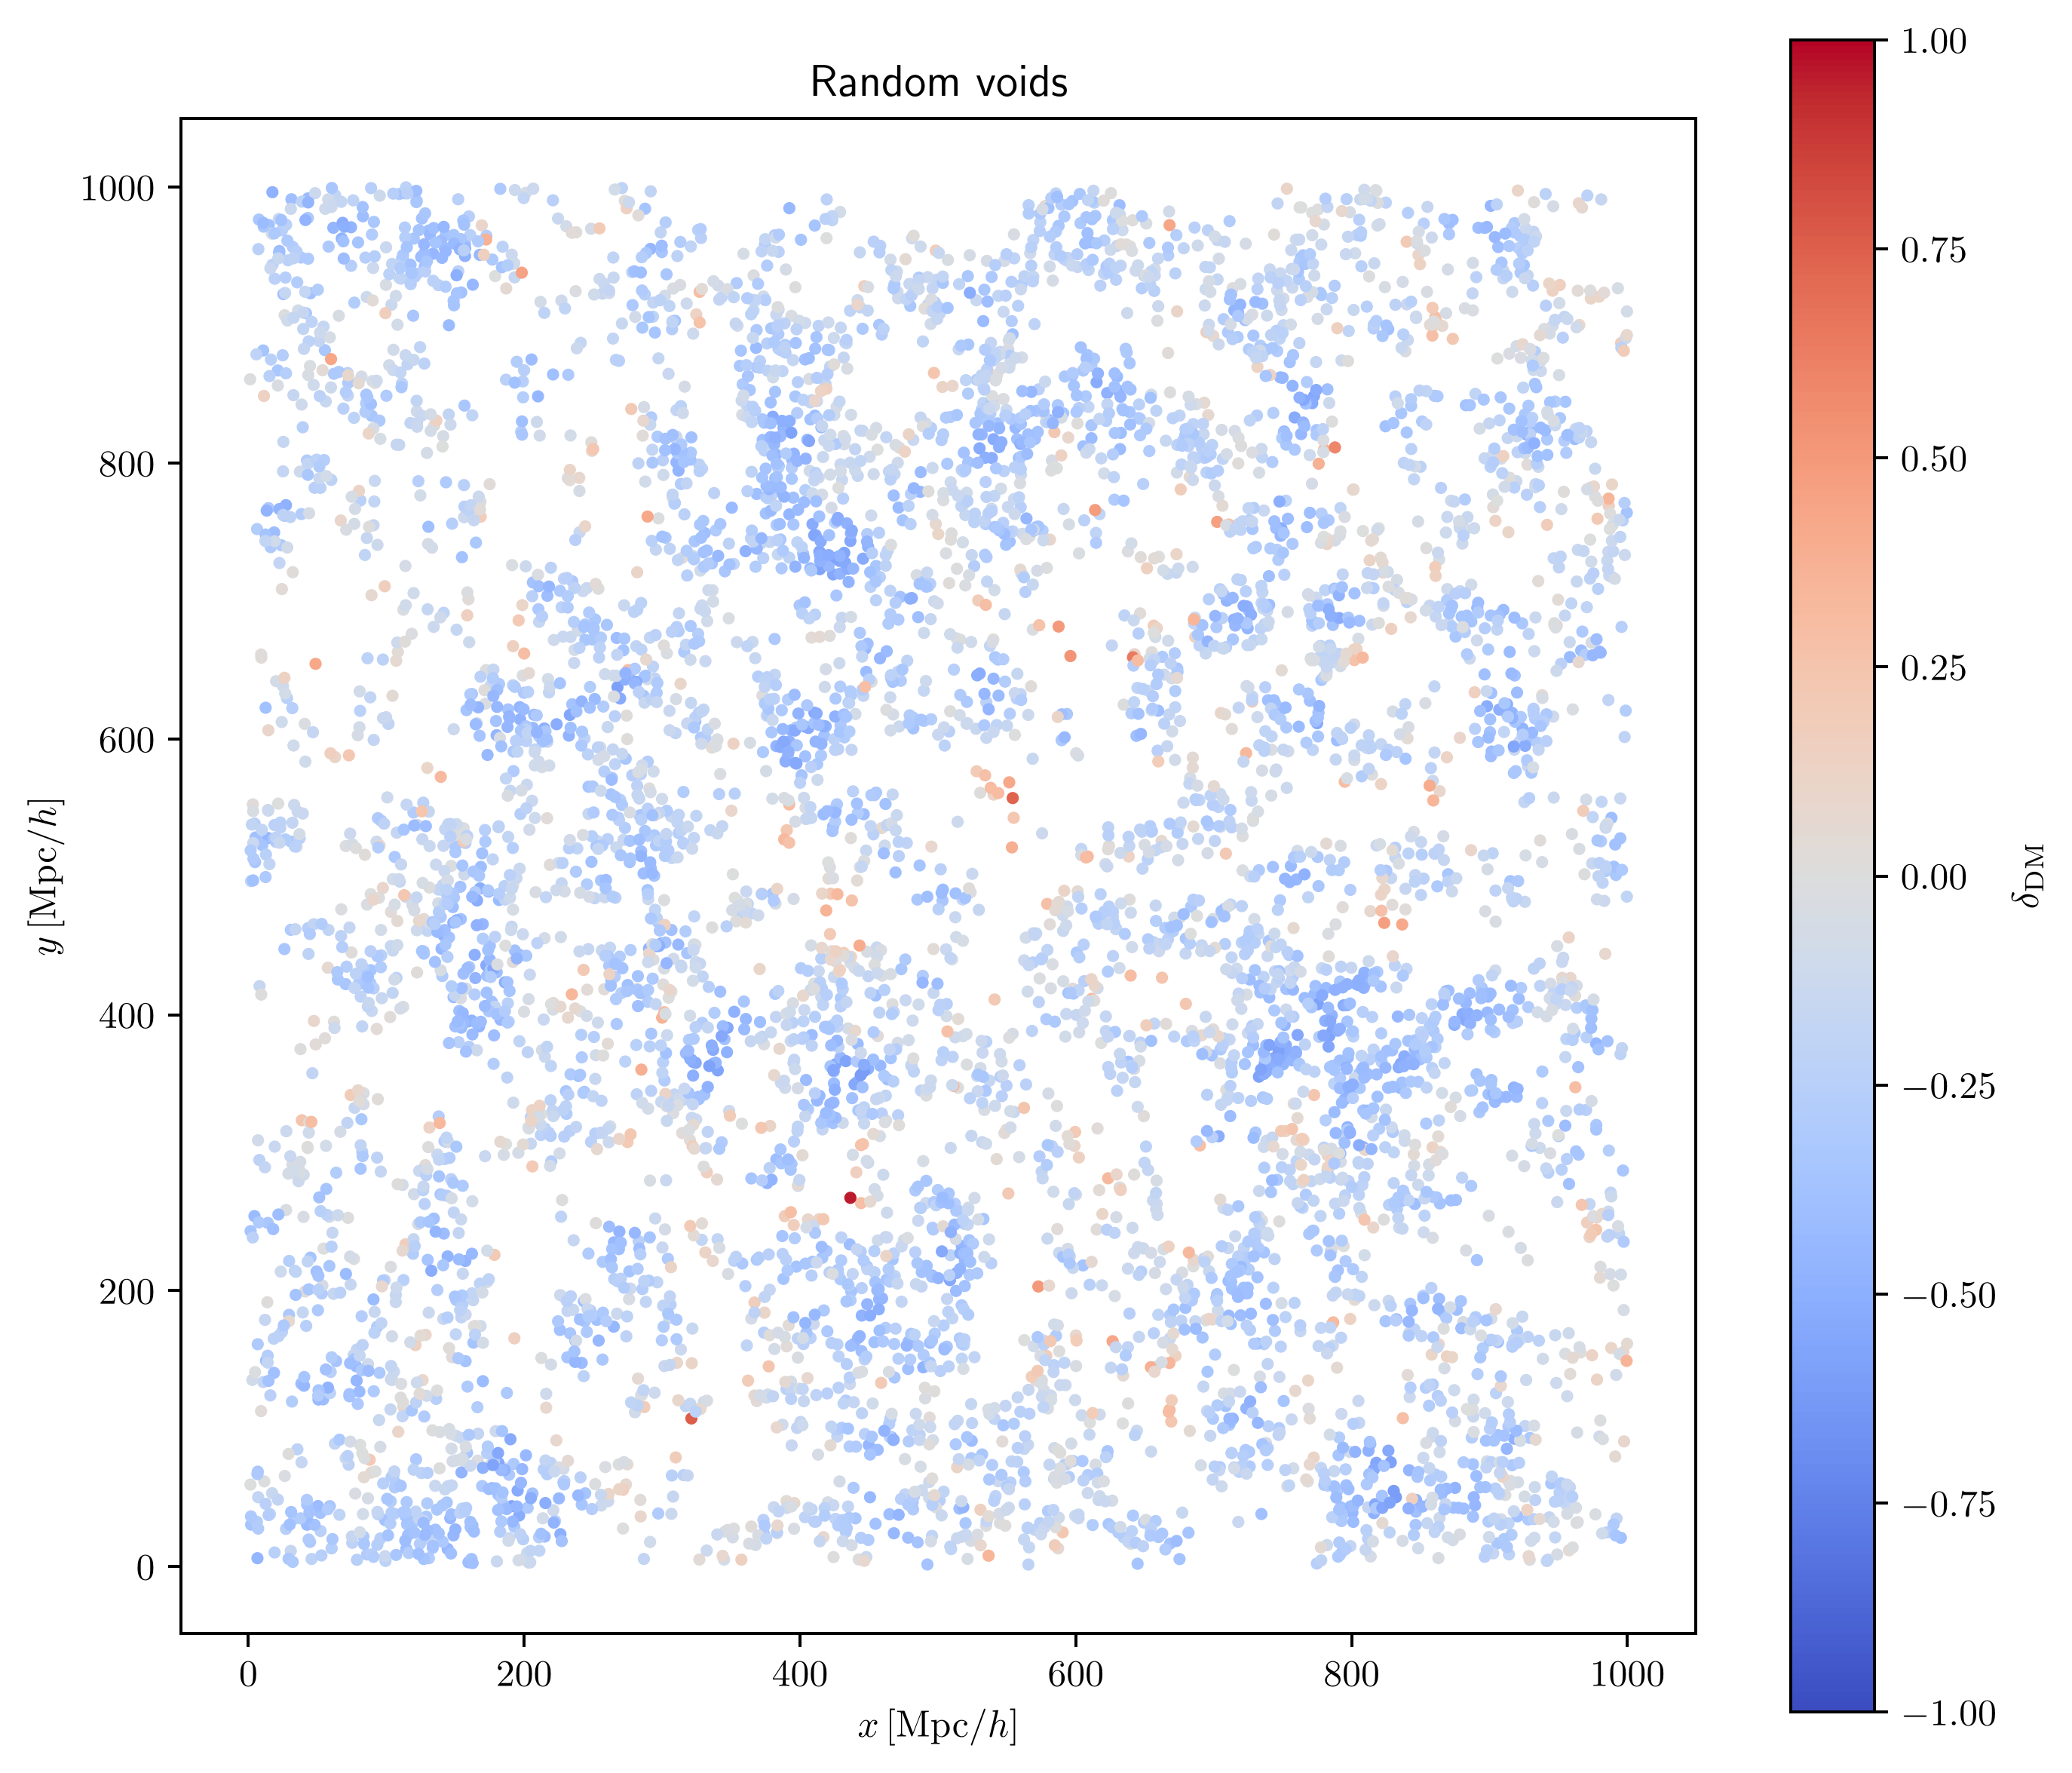

In [72]:
fig, ax = plt.subplots(figsize=(9, 8))

sc = ax.scatter(p[:, 0], p[:, 1], c=delta, s=5, cmap='coolwarm', vmin=-1, vmax=1)

plt.colorbar(sc, ax=ax, label=r'$\delta_{\rm DM}$')

ax.set_xlabel(r'$x\,[{\rm Mpc}/h]$')
ax.set_ylabel(r'$y\,[{\rm Mpc}/h]$')
ax.set_aspect('equal')
ax.set_title('Random voids')

plt.show()

In [73]:
src = data.edge_index[0].cpu().numpy()
dst = data.edge_index[1].cpu().numpy()

slice_mask = (random_mask & (np.abs(pos_np[:, 2] - z0) < dz/2))

In [74]:
edge_mask = (random_mask[src] & random_mask[dst] &
             slice_mask[src] & slice_mask[dst] & (src < dst))

src_plot = src[edge_mask]
dst_plot = dst[edge_mask]

In [75]:
p1 = pos_np[src_plot]
p2 = pos_np[dst_plot]

delta_raw = p2 - p1 # los que van de extremos

In [76]:
Lbox = 1000.
periodic_cross = ((np.abs(delta_raw[:, 0]) > Lbox/2) | (np.abs(delta_raw[:, 1]) > Lbox/2))

In [77]:
p1 = p1[~periodic_cross]
p2 = p2[~periodic_cross]

segments = np.stack([p1[:, :2], p2[:, :2]], axis=1)
segments.shape

(52392, 2, 2)

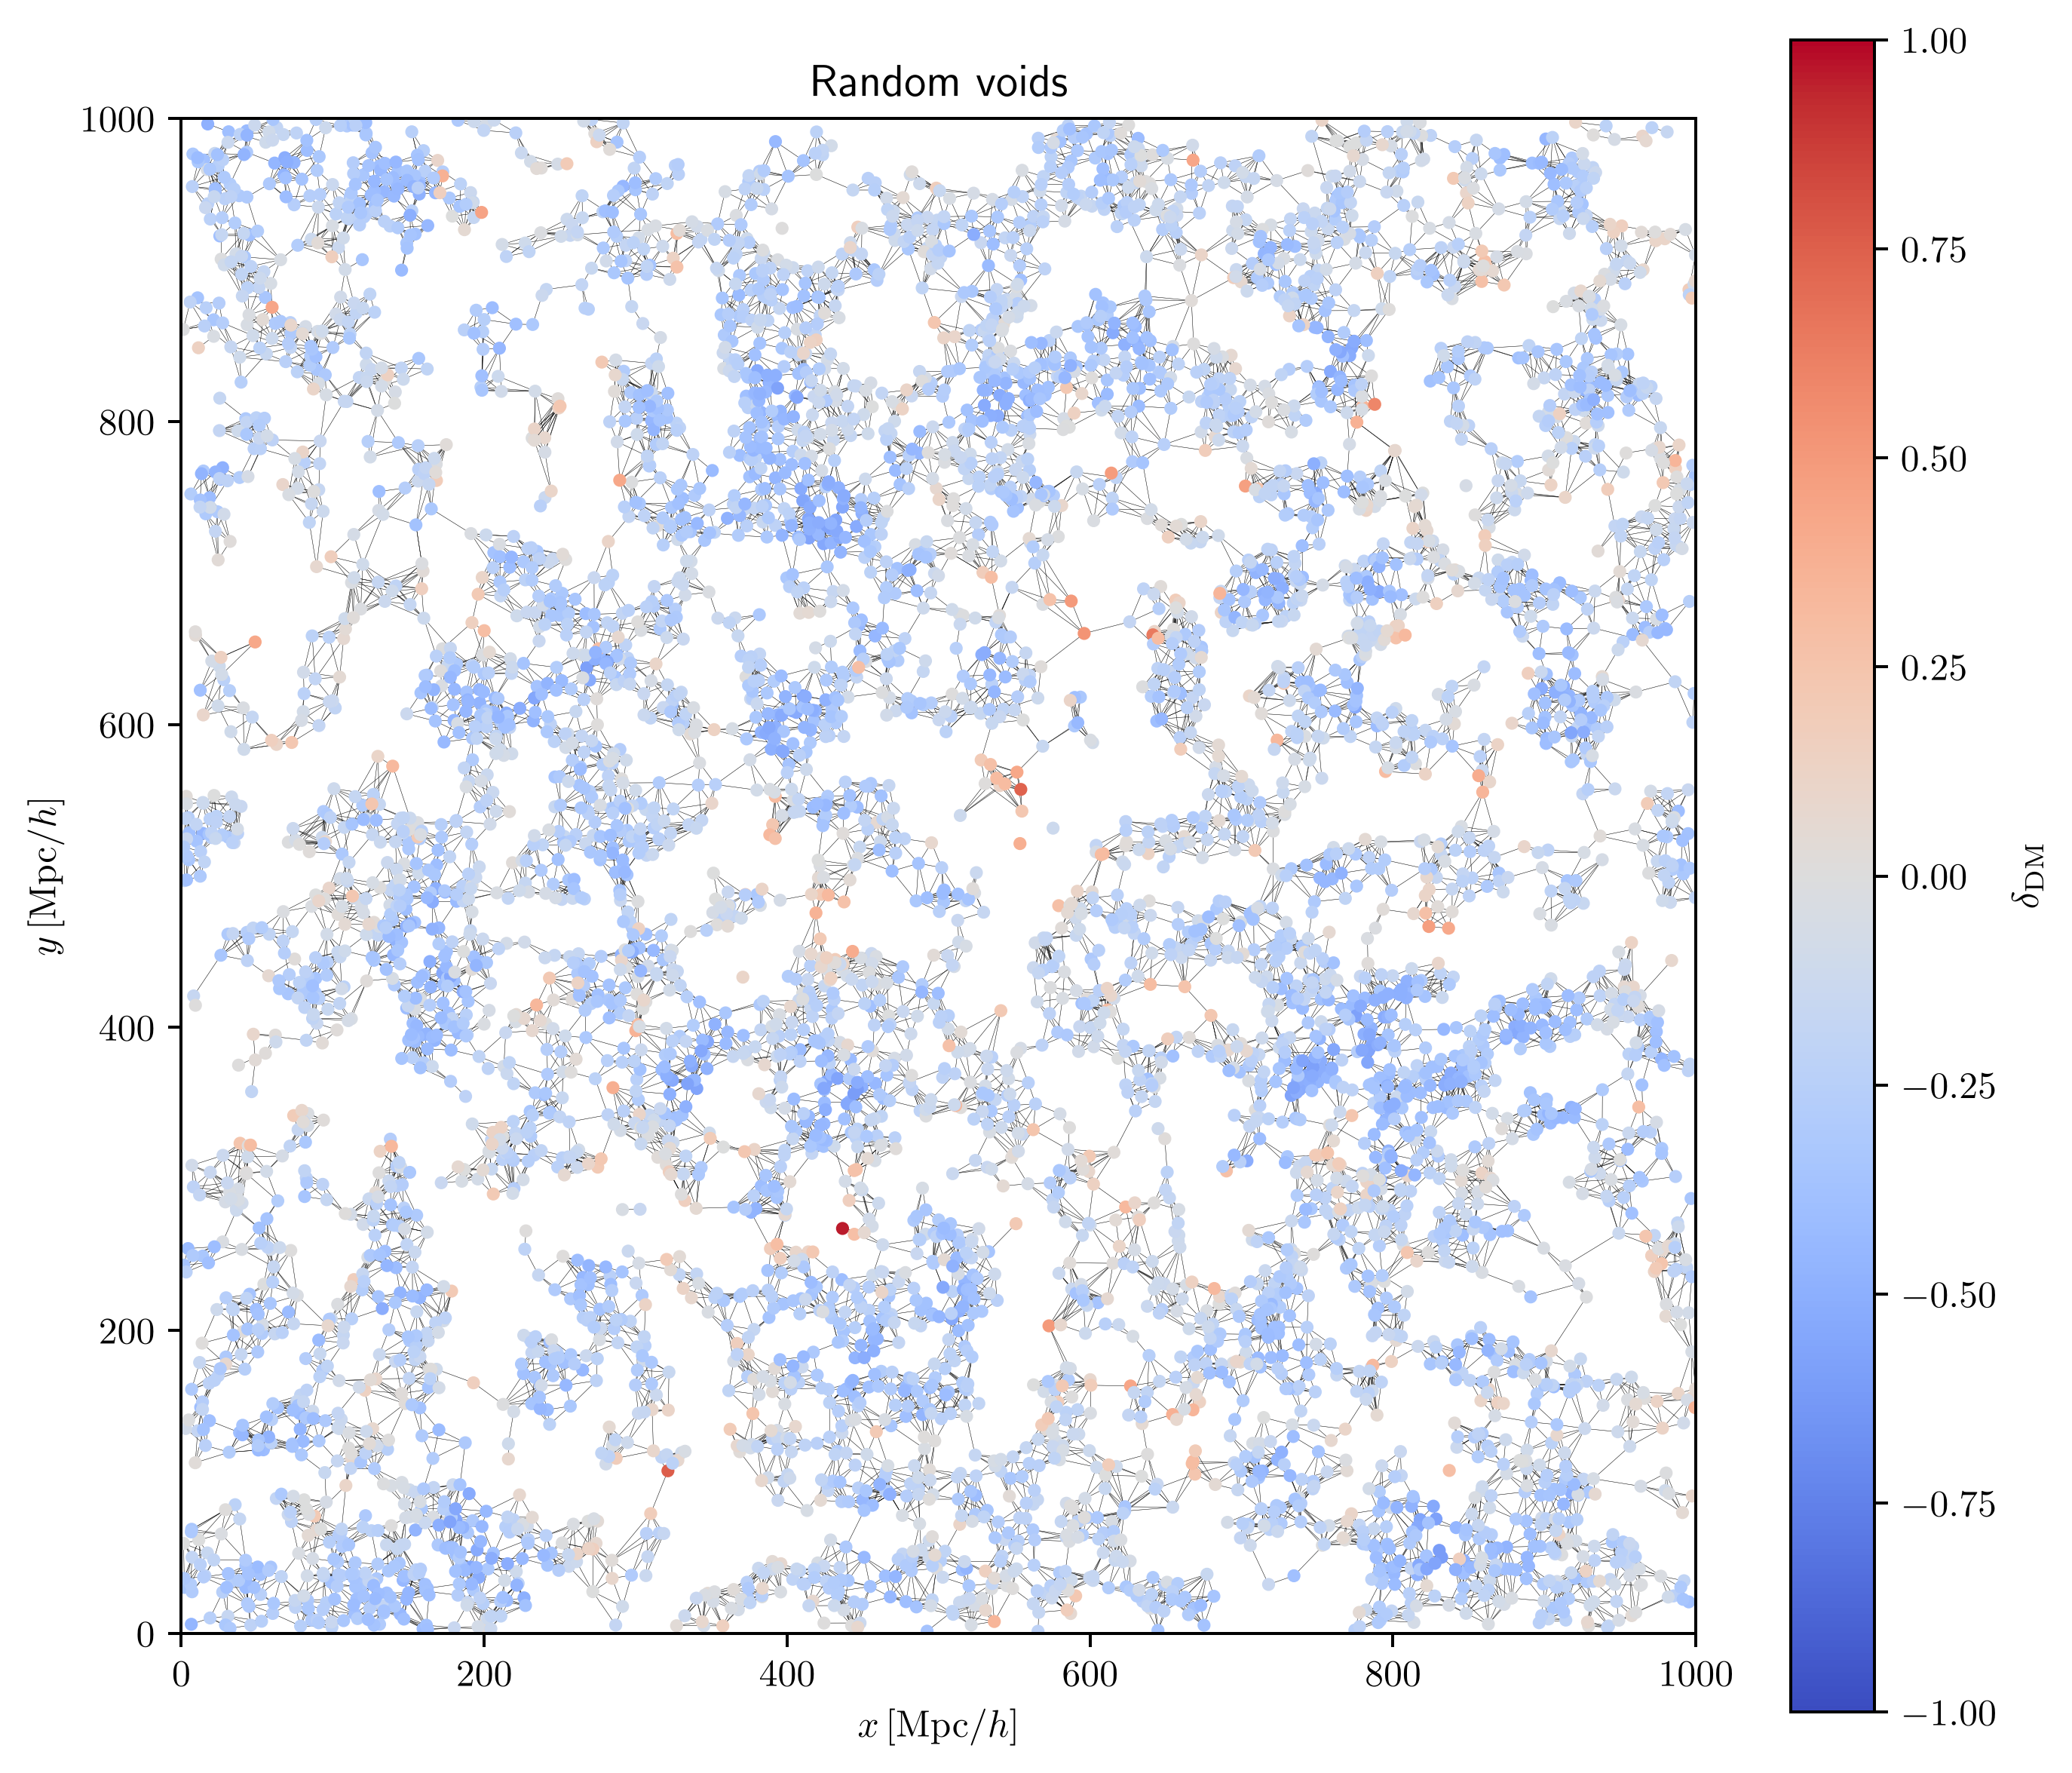

In [84]:
fig, ax = plt.subplots(figsize=(9, 8))

lc = LineCollection(segments, linewidths=0.1, alpha=0.6, color='black')
ax.add_collection(lc)

p = pos_np[slice_mask]
delta = y_np[slice_mask]

sc = ax.scatter(p[:, 0], p[:, 1], c=delta, s=6, cmap='coolwarm',
                vmin=-1, vmax=1, zorder=2)#, linewidths=0.1, edgecolors='black')

plt.colorbar(sc, ax=ax, label=r'$\delta_{\rm DM}$')

ax.set_xlim(0, 1000)
ax.set_ylim(0, 1000)

ax.set_xlabel(r'$x\,[{\rm Mpc}/h]$')
ax.set_ylabel(r'$y\,[{\rm Mpc}/h]$')
ax.set_aspect('equal')
ax.set_title('Random voids')

plt.show()